In [ ]:
import pandas as pd
from google.colab import drive
!pip install shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score # Import f1_score here
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from xgboost import XGBClassifier # Import XGBClassifier
import lightgbm as lgb
lgb.LGBMClassifier(verbosity=-1)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import numpy as np

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Heart Disease/heart_dataset.csv')
df.head()

,Unnamed: 0,household_id,total_income,union_name,user_id,profile_name,father_name,mother_name,birthday,age,...,RESULT_STAT_SPO2,MUAC,RESULT_STAT_MUAC,chest_pain_type,shortness_of_breath,smoking_status,family_history_hd,physical_activity,diet_type,source
0,6771.0,279900.0,Middle class,CHERAGPUR,1111051.0,আফরোজাআক্তার,আশরাফুল,তানজিলা খাতুন,09-03-04 18:00,16.0,...,Normal,NaN,NaN,No chest pain,Frequently,Never,No,No,Moderate,kaggle
1,29319.0,353384.0,Lower class,ANDULBARIA,1392877.0,সালমাবেগম,0,0,11-07-89 18:00,31.0,...,NaN,NaN,NaN,No chest pain,Frequently,Never,Yes,No,Moderate,kaggle
2,67.0,241330.0,Lower class,KOLA,989244.0,হাজেরাবেগম,0,0,02-01-57 18:00,63.0,...,NaN,NaN,NaN,During physical activity,Frequently,Never,Yes,Yes,Moderate,kaggle
3,11645.0,14151.0,Lower class,BARATARA,103371.0,মোছাঃ নুরুন্নাহার বেগম,0,0,25-02-82 14:12,38.0,...,NaN,NaN,NaN,After emotional stress or meals,NaN,NaN,NaN,NaN,NaN,kaggle
4,1260.0,261386.0,Middle class,KOLA,1049014.0,মোঃ মতিউররহমান,0,0,31-05-68 18:00,52.0,...,NaN,NaN,NaN,No chest pain,Frequently,Never,Yes,Yes,Moderate,kaggle


In [ ]:
df.columns

Index(['Unnamed: 0', 'household_id', 'total_income', 'union_name', 'user_id',
       'profile_name', 'father_name', 'mother_name', 'birthday', 'age',
       'gender', 'is_poor', 'is_freedom_fighter', 'had_stroke',
       'has_cardiovascular_disease', 'disabilities_name', 'diabetic',
       'profile_hypertensive', 'SYSTOLIC', 'DIASTOLIC', 'RESULT_STAT_BP',
       'HEIGHT', 'WEIGHT', 'BMI', 'RESULT_STAT_BMI', 'SUGAR', 'TAG_NAME',
       'RESULT_STAT_SUGAR', 'PULSE_RATE', 'RESULT_STAT_PR', 'SPO2',
       'RESULT_STAT_SPO2', 'MUAC', 'RESULT_STAT_MUAC', 'chest_pain_type',
       'shortness_of_breath', 'smoking_status', 'family_history_hd',
       'physical_activity', 'diet_type', 'source'],
      dtype='object')

In [ ]:
df["age"] = df["age"].astype("Int64")  # nullable integer

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1961 entries, 0 to 1960
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1908 non-null   float64
 1   household_id                1908 non-null   float64
 2   total_income                1908 non-null   object 
 3   union_name                  1908 non-null   object 
 4   user_id                     1908 non-null   float64
 5   profile_name                1908 non-null   object 
 6   father_name                 1876 non-null   object 
 7   mother_name                 1875 non-null   object 
 8   birthday                    1908 non-null   object 
 9   age                         1960 non-null   Int64  
 10  gender                      1961 non-null   object 
 11  is_poor                     1908 non-null   float64
 12  is_freedom_fighter          1908 non-null   float64
 13  had_stroke                  1961 

In [ ]:
df.shape

(1961, 41)

In [ ]:
columns_to_keep = [
    'age',
    'gender',
    'chest_pain_type',
    'SYSTOLIC',
    'SUGAR',
    'PULSE_RATE',
    'shortness_of_breath',
    'RESULT_STAT_BP',
    'BMI',
    'has_cardiovascular_disease',
    'family_history_hd',
    'smoking_status',
    'diabetic',
    'profile_hypertensive',
    'physical_activity',
    'diet_type',
]
df = df[columns_to_keep]


In [ ]:
df.shape

(1961, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1961 entries, 0 to 1960
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1960 non-null   Int64  
 1   gender                      1961 non-null   object 
 2   chest_pain_type             1961 non-null   object 
 3   SYSTOLIC                    1905 non-null   float64
 4   SUGAR                       779 non-null    float64
 5   PULSE_RATE                  1902 non-null   float64
 6   shortness_of_breath         1650 non-null   object 
 7   RESULT_STAT_BP              1905 non-null   object 
 8   BMI                         815 non-null    float64
 9   has_cardiovascular_disease  1941 non-null   float64
 10  family_history_hd           1650 non-null   object 
 11  smoking_status              1650 non-null   object 
 12  diabetic                    1961 non-null   object 
 13  profile_hypertensive        1961 

In [ ]:
# Split X and y
X = df.drop('has_cardiovascular_disease', axis=1)
y = df['has_cardiovascular_disease']

In [ ]:
# Fill missing values in y with the mode
y = y.fillna(y.mode()[0])

In [ ]:
# Identify numerical and categorical columns in X
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()


In [ ]:
# Fill missing values in numerical columns with median
for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill missing values in categorical columns with mode
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])


In [ ]:
# Encode categorical features
X = pd.get_dummies(X)

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print(df['diabetic'].value_counts())
print(df['profile_hypertensive'].value_counts())
print(df['has_cardiovascular_disease'].value_counts())
print(df['shortness_of_breath'].value_counts())

diabetic
0           1850
1             99
Not sure      11
Yes            1
Name: count, dtype: int64
profile_hypertensive
0           1809
1            133
Not sure      15
Yes            4
Name: count, dtype: int64
has_cardiovascular_disease
1.0    1573
0.0     368
Name: count, dtype: int64
shortness_of_breath
Frequently      1298
Rarely           208
Never            136
Occasionally       8
Name: count, dtype: int64


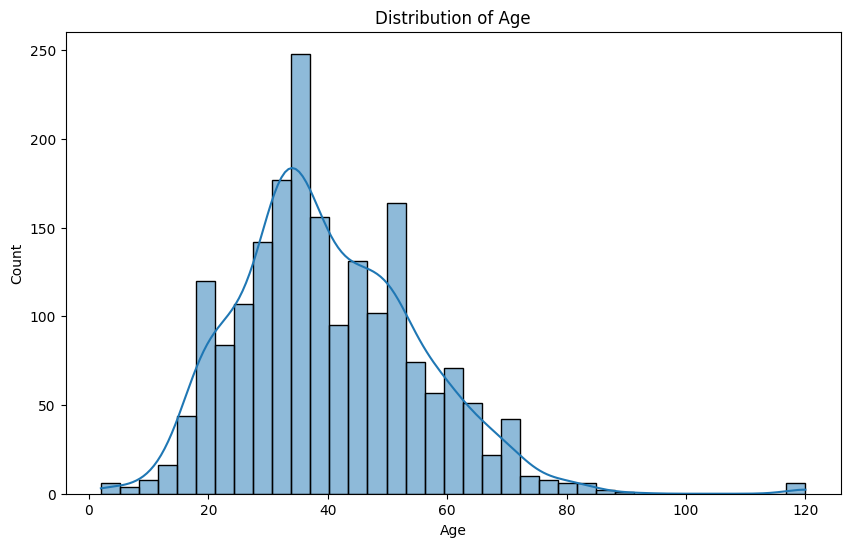

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


/tmp/ipython-input-376760981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='gender', y='age', palette={'Male': '#1f77b4', 'Female': '#ff7f0e'})


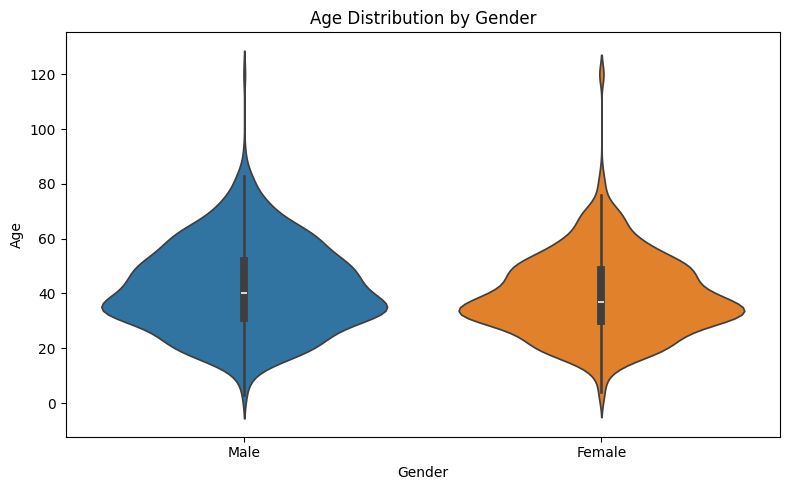

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='gender', y='age', palette={'Male': '#1f77b4', 'Female': '#ff7f0e'})
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


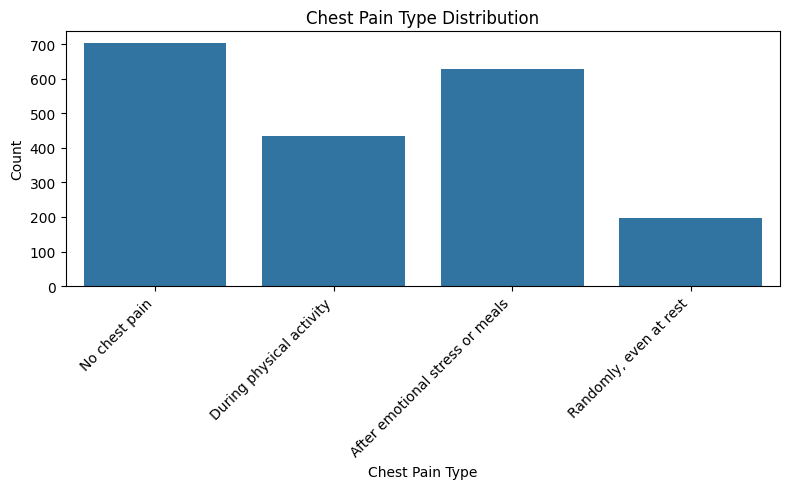

In [ ]:
# Chest pain type distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='chest_pain_type', data=df)
plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup for clean visuals
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


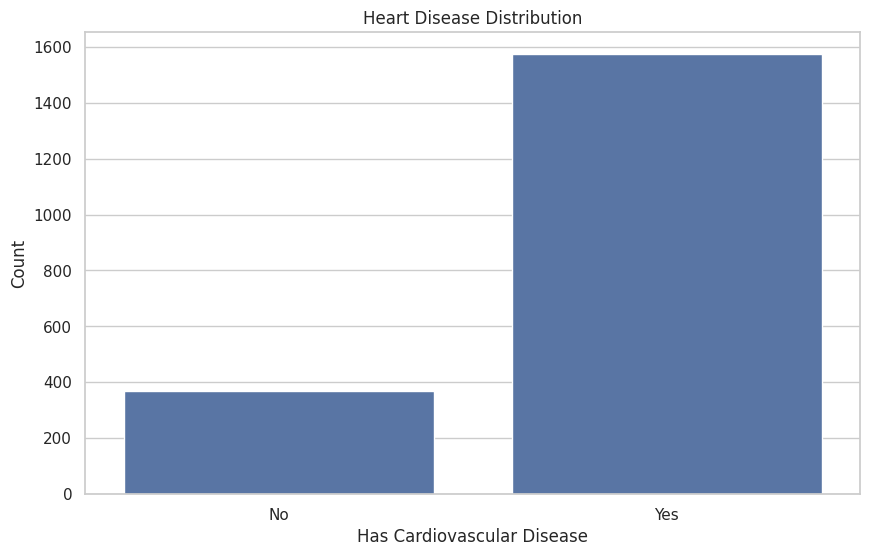

In [ ]:
sns.countplot(x='has_cardiovascular_disease', data=df)
plt.title('Heart Disease Distribution')
plt.xlabel('Has Cardiovascular Disease')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


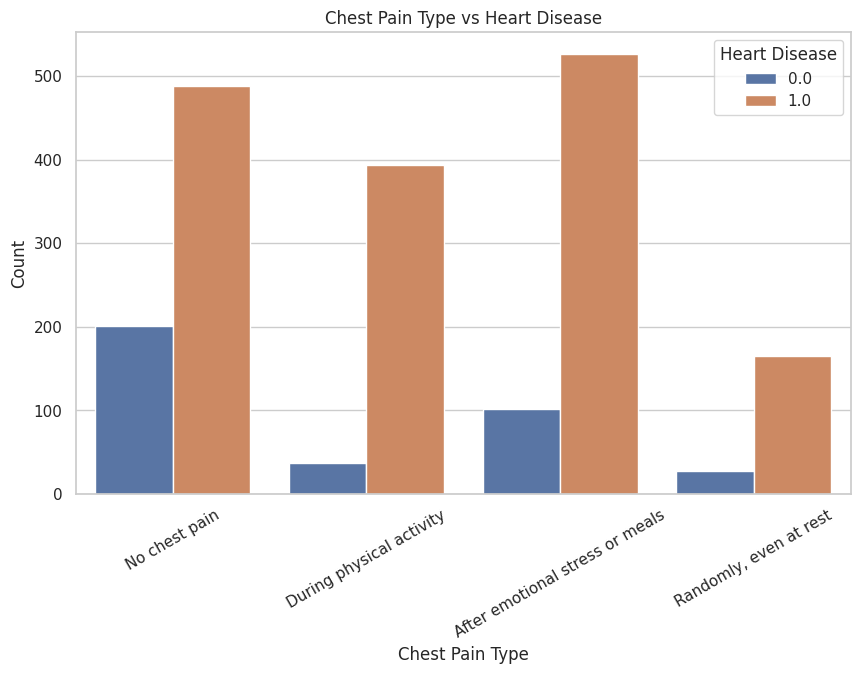

In [ ]:
sns.countplot(x='chest_pain_type', hue='has_cardiovascular_disease', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Heart Disease')
plt.show()


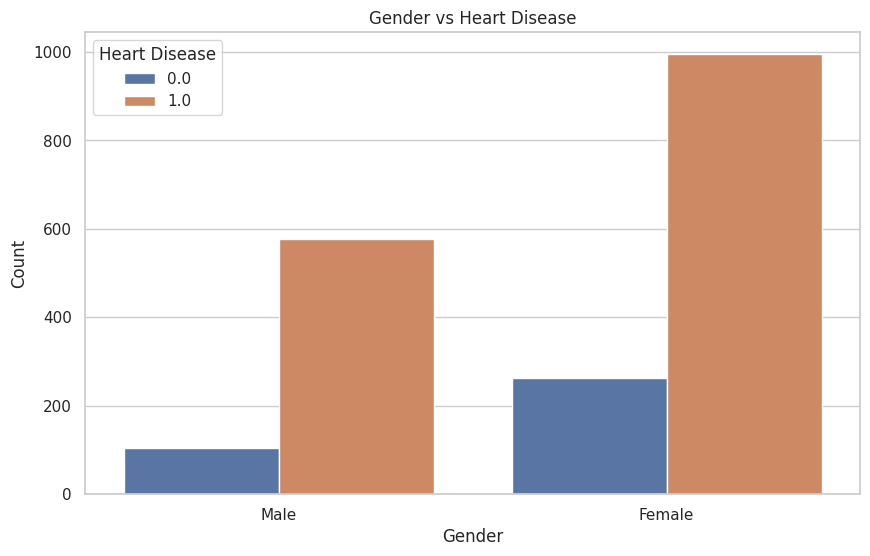

In [ ]:
sns.countplot(x='gender', hue='has_cardiovascular_disease', data=df)
plt.title('Gender vs Heart Disease')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.show()


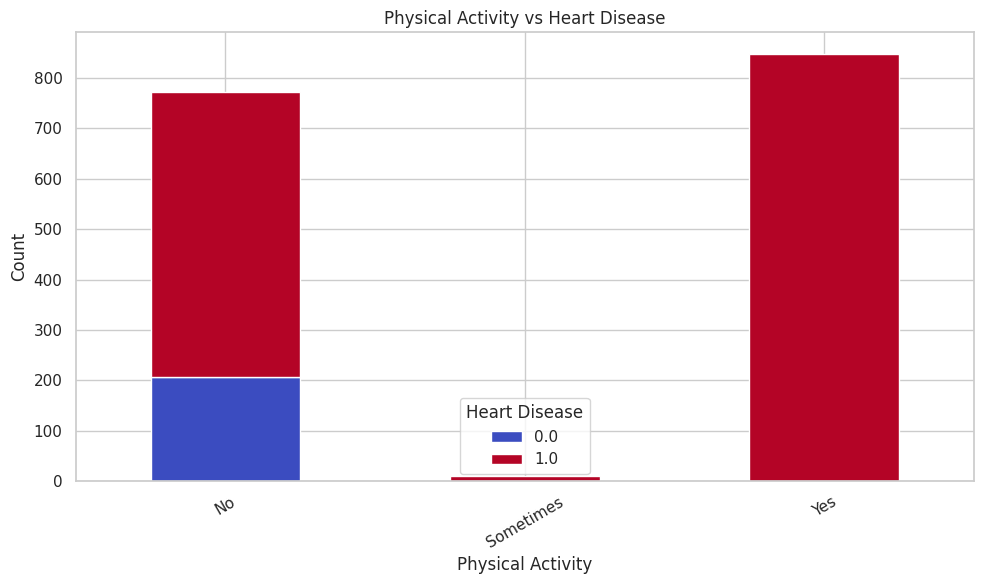

In [ ]:
activity_counts = pd.crosstab(df['physical_activity'], df['has_cardiovascular_disease'])
activity_counts.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Physical Activity vs Heart Disease')
plt.xlabel('Physical Activity')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


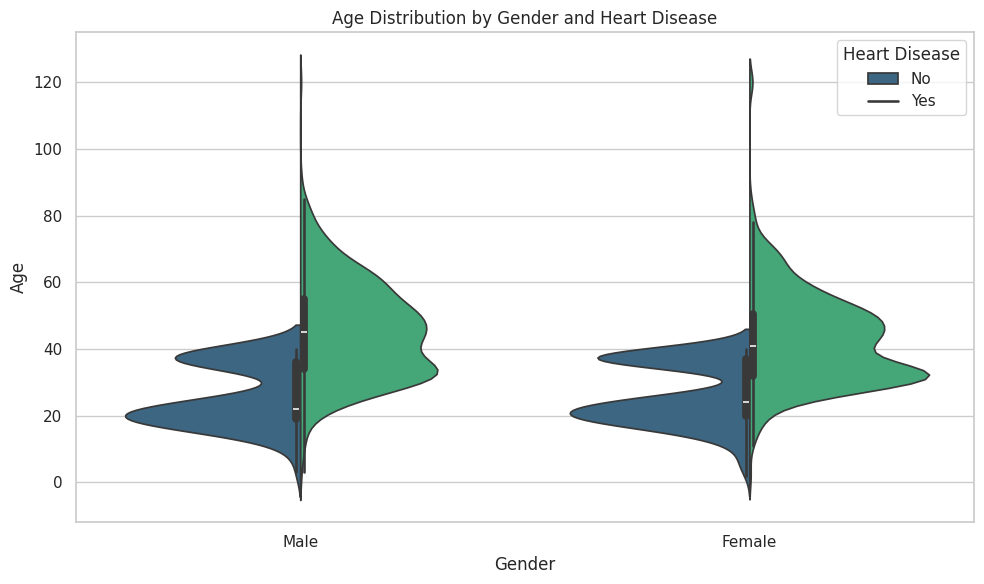

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='gender', y='age', hue='has_cardiovascular_disease', data=df, palette='viridis', split=True)
plt.title('Age Distribution by Gender and Heart Disease')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.legend(title='Heart Disease', loc='upper right', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

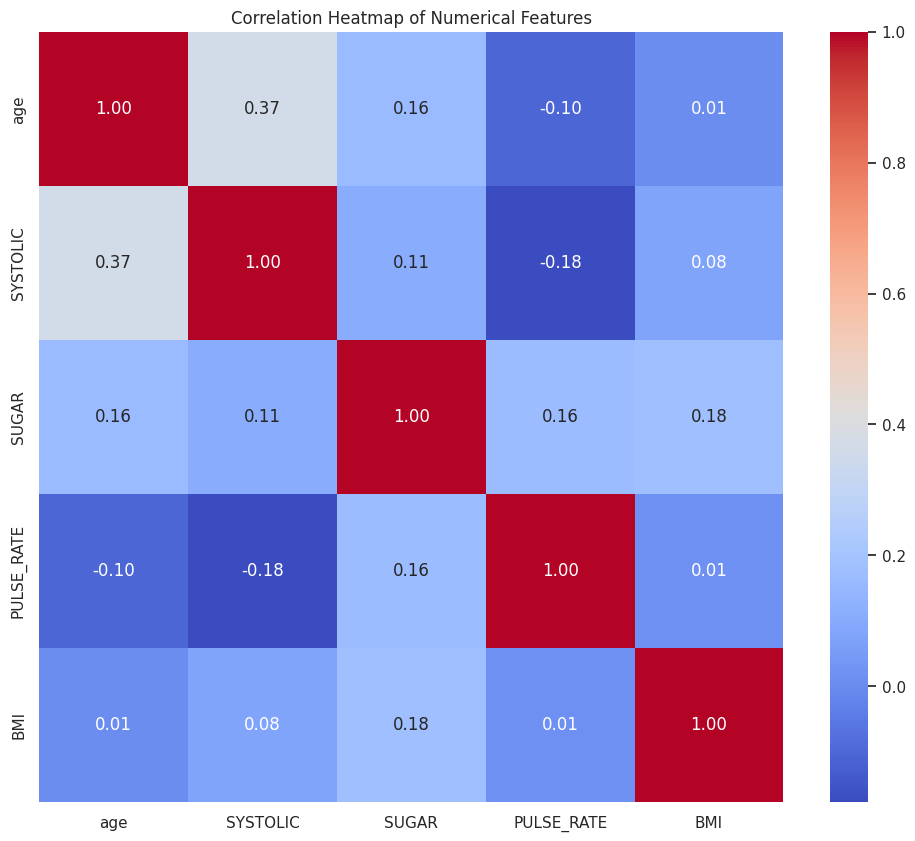

In [ ]:
# Select only numerical columns for correlation analysis
numerical_df = df[numerical_cols]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Inject label noise
from sklearn.feature_selection import SelectFromModel
noise_ratio = 0.05
n_noisy = int(noise_ratio * len(y_train))
noisy_indices = np.random.choice(len(y_train), n_noisy, replace=False)
y_train_noisy = y_train.copy()
y_train_noisy.iloc[noisy_indices] = 1 - y_train_noisy.iloc[noisy_indices]

# Feature selection (optional now due to column curation)
selector = SelectFromModel(RandomForestClassifier(n_estimators=50, random_state=42))
selector.fit(X_train, y_train_noisy)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

In [ ]:
# Reduce training set to simulate smaller sample learning
X_train_partial, _, y_train_partial, _ = train_test_split(X_train_sel, y_train_noisy, train_size=0.7, random_state=42)

# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_split=20),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=6),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=4, n_estimators=60),
    "SVM": SVC(probability=True, C=0.8),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Net": MLPClassifier(max_iter=500, alpha=0.001, early_stopping=True)
}

# Train & evaluate
results = []
for name, model in models.items():
    model.fit(X_train_partial, y_train_partial)
    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    results.append((name, acc, f1, roc))
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")
    if roc is not None:
        print(f"ROC AUC: {roc:.4f}")
    print(classification_report(y_test, y_pred))

# Print model ranking
results.sort(key=lambda x: x[1], reverse=True)
print("\n--- Model Accuracy Ranking (Filtered Features) ---")
for name, acc, f1, roc in results:
    if roc is not None:
        print(f"{name}: Accuracy={acc:.4f}")
    else:
        print(f"{name}: Accuracy={acc:.4f}")


Decision Tree Accuracy: 0.9466
F1 Score (Macro): 0.9195
ROC AUC: 0.9676
              precision    recall  f1-score   support

         0.0       0.79      0.97      0.87        74
         1.0       0.99      0.94      0.97       319

    accuracy                           0.95       393
   macro avg       0.89      0.96      0.92       393
weighted avg       0.96      0.95      0.95       393


Random Forest Accuracy: 0.9186
F1 Score (Macro): 0.8488
ROC AUC: 0.9722
              precision    recall  f1-score   support

         0.0       0.90      0.64      0.75        74
         1.0       0.92      0.98      0.95       319

    accuracy                           0.92       393
   macro avg       0.91      0.81      0.85       393
weighted avg       0.92      0.92      0.91       393



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:53:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.9618
F1 Score (Macro): 0.9372
ROC AUC: 0.9801
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90        74
         1.0       0.97      0.98      0.98       319

    accuracy                           0.96       393
   macro avg       0.94      0.93      0.94       393
weighted avg       0.96      0.96      0.96       393


SVM Accuracy: 0.8982
F1 Score (Macro): 0.8134
ROC AUC: 0.8029
              precision    recall  f1-score   support

         0.0       0.81      0.59      0.69        74
         1.0       0.91      0.97      0.94       319

    accuracy                           0.90       393
   macro avg       0.86      0.78      0.81       393
weighted avg       0.89      0.90      0.89       393


Naive Bayes Accuracy: 0.8830
F1 Score (Macro): 0.7931
ROC AUC: 0.8517
              precision    recall  f1-score   support

         0.0       0.73      0.59      0.66        74
         1.0       0.91      0.95   

In [ ]:
print(len(X_train_partial))
print(len(y_train_partial))
print(len(X_test_sel))
print(len(y_test))
print(len(X_train_sel))
print(len(X_test))

1097
1097
393
393
1568
393


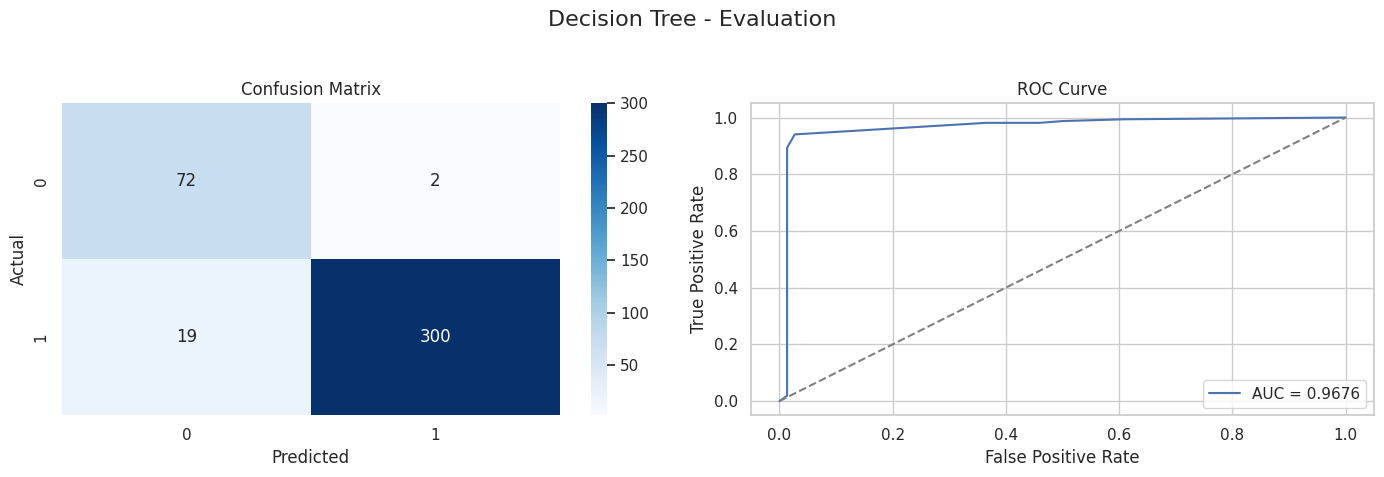

=== Completed Plot for Model: Decision Tree ===


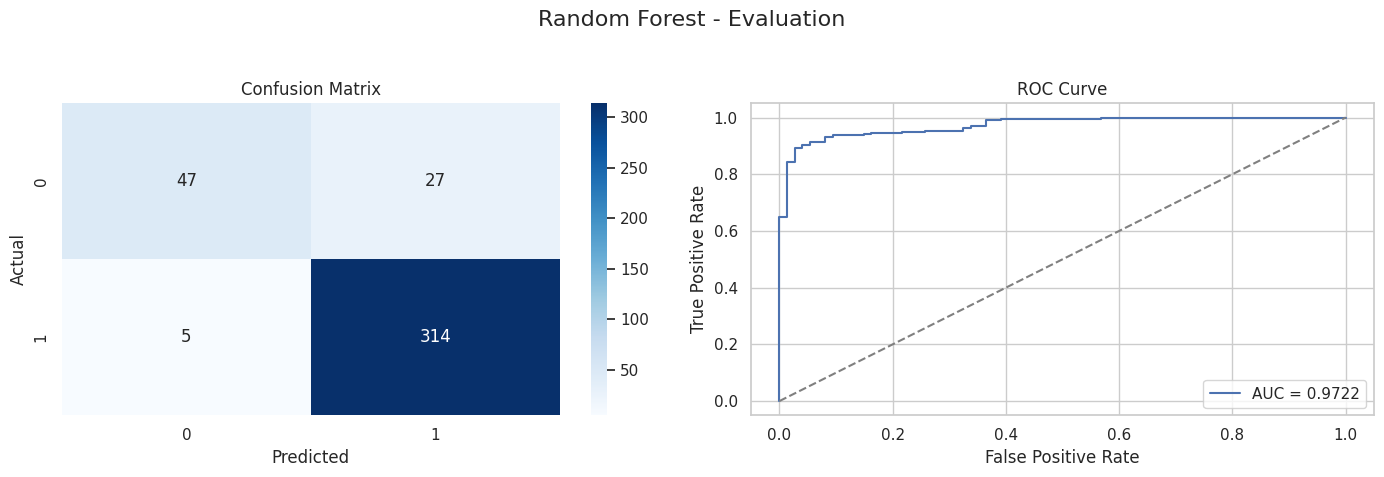

=== Completed Plot for Model: Random Forest ===


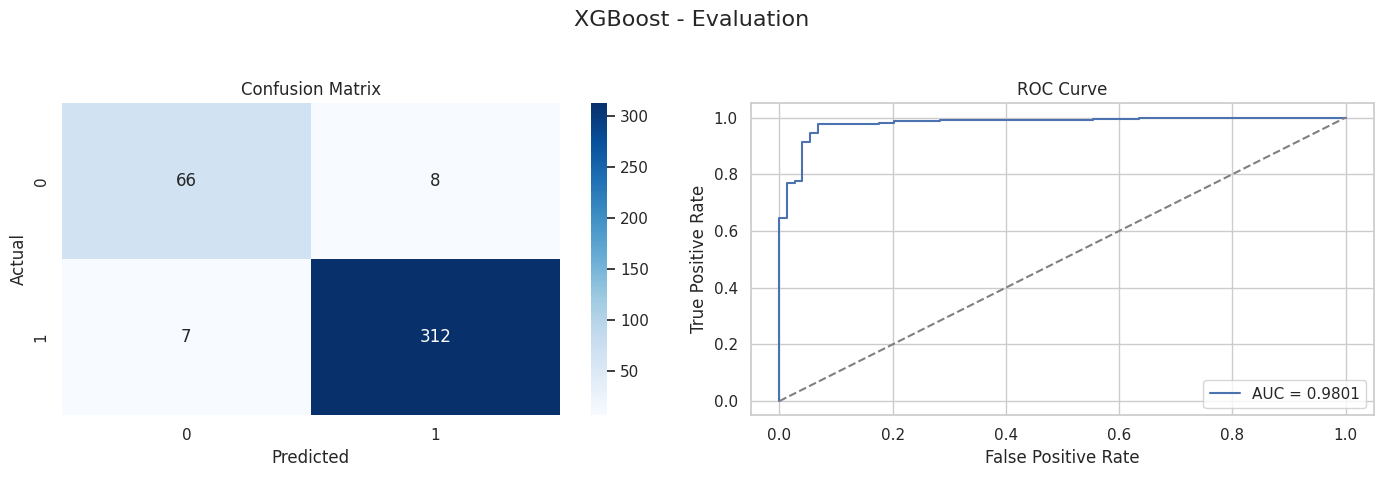

=== Completed Plot for Model: XGBoost ===


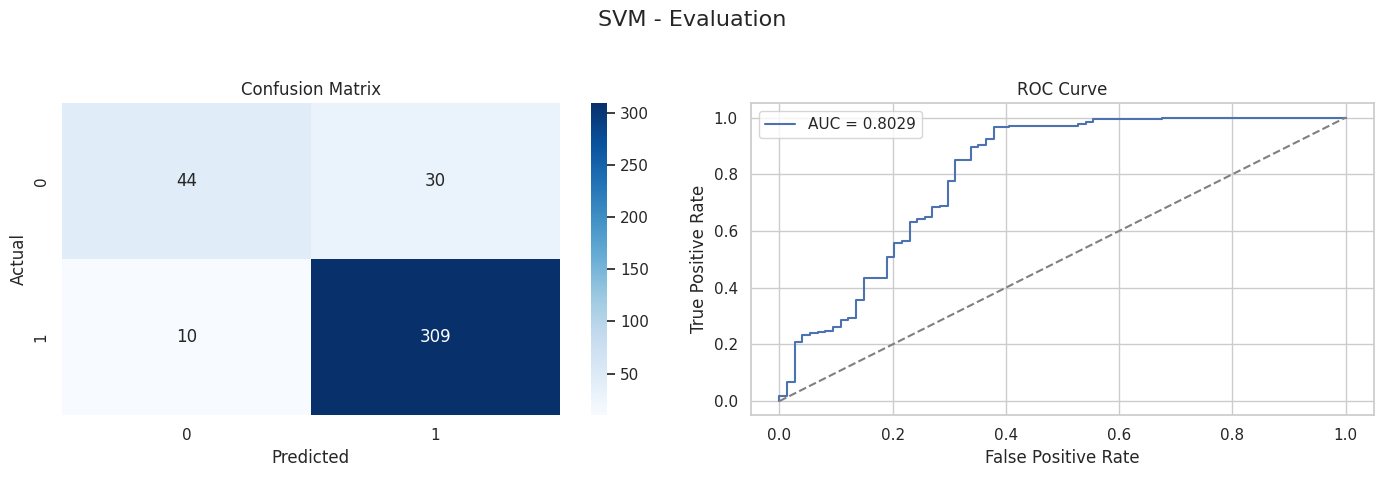

=== Completed Plot for Model: SVM ===


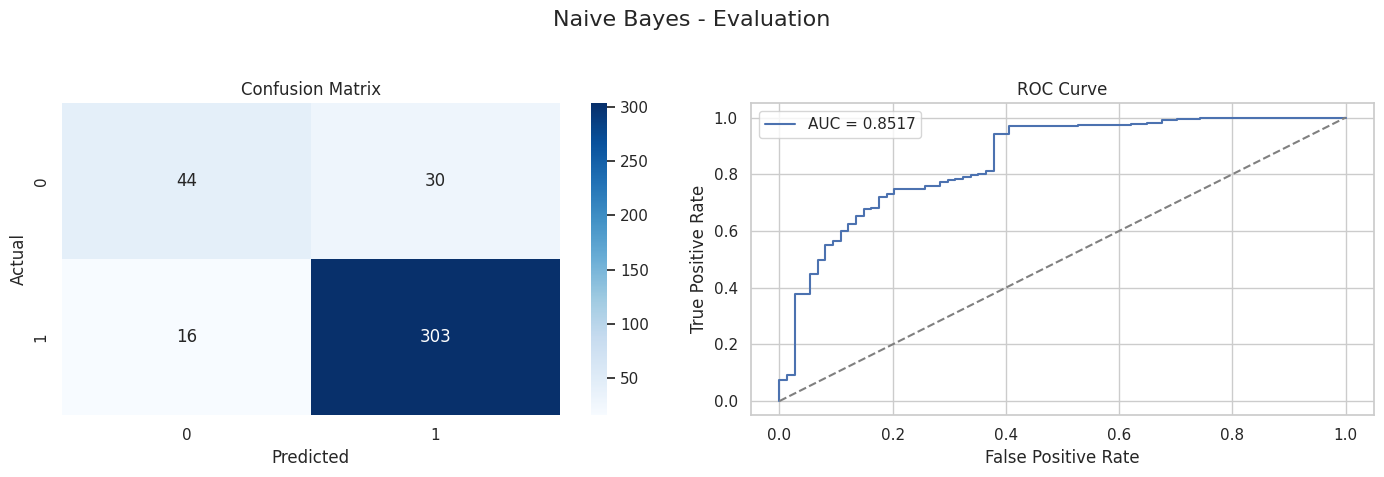

=== Completed Plot for Model: Naive Bayes ===


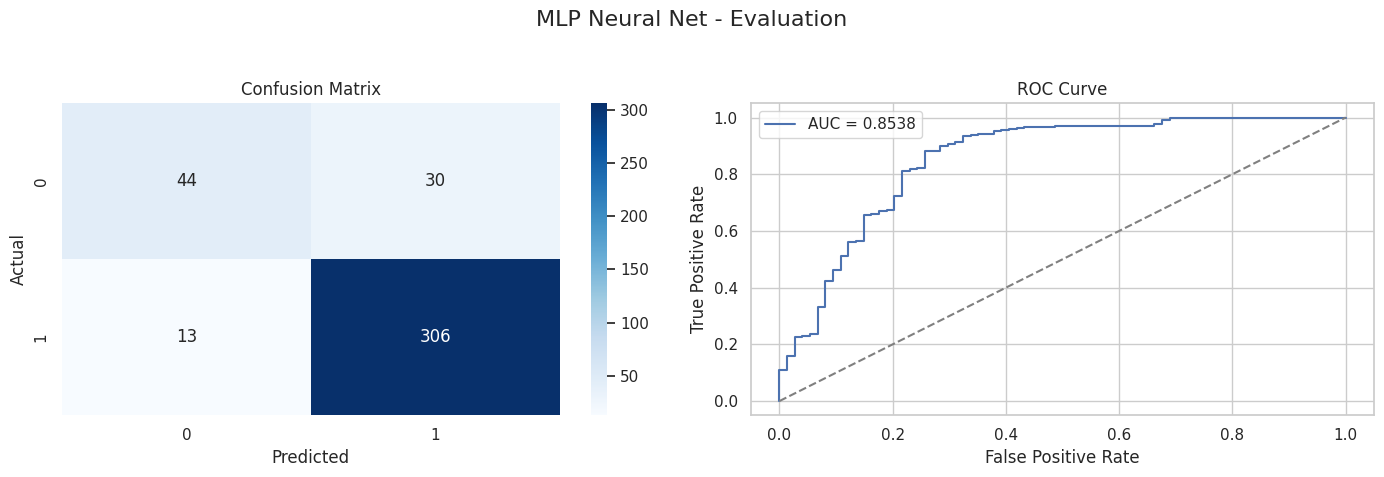

=== Completed Plot for Model: MLP Neural Net ===


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

for name, model in models.items():  # ✅ use trained models
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)

    y_prob = model.predict_proba(X_test_sel)[:, 1] if hasattr(model, "predict_proba") else None
    fpr, tpr, _ = roc_curve(y_test, y_prob) if y_prob is not None else (None, None, None)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{name} - Evaluation", fontsize=16)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    if y_prob is not None:
        axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
        axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
        axes[1].set_title("ROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'ROC not available', horizontalalignment='center', verticalalignment='center', fontsize=12)
        axes[1].set_axis_off()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print(f"=== Completed Plot for Model: {name} ===")


/tmp/ipython-input-872360827.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies, y=model_names, palette='viridis')


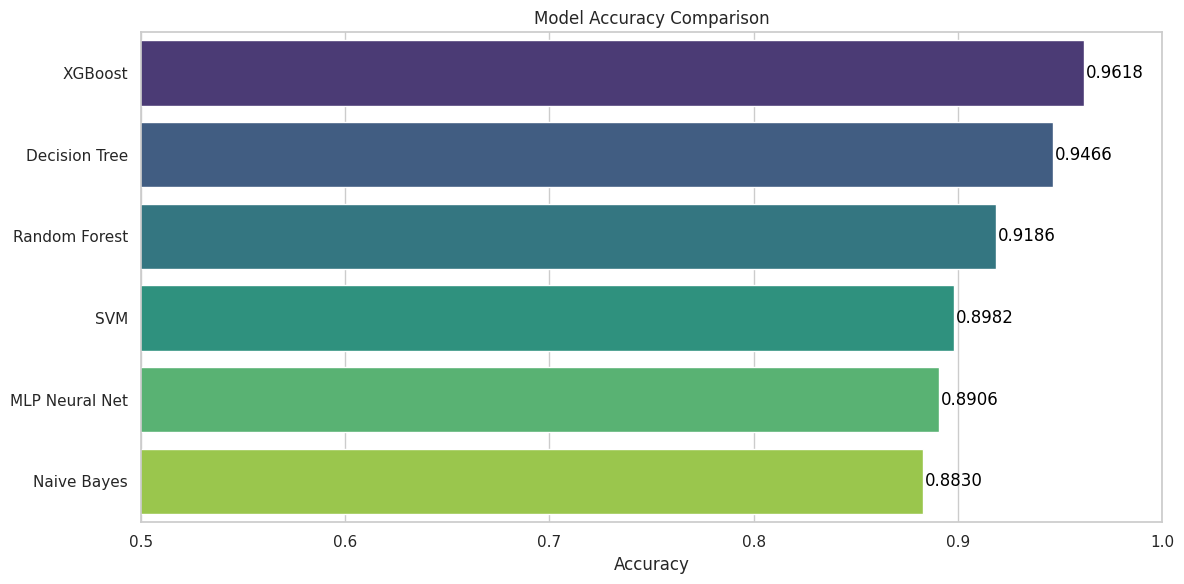

In [ ]:
# Sort by accuracy
results.sort(key=lambda x: x[1], reverse=True)
model_names = [r[0] for r in results]
accuracies = [r[1] for r in results]
plt.figure(figsize=(12, 6))
sns.barplot(x=accuracies, y=model_names, palette='viridis')
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, v in enumerate(accuracies):
    plt.text(v + 0.001, i, f"{v:.4f}", color='black', va='center')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


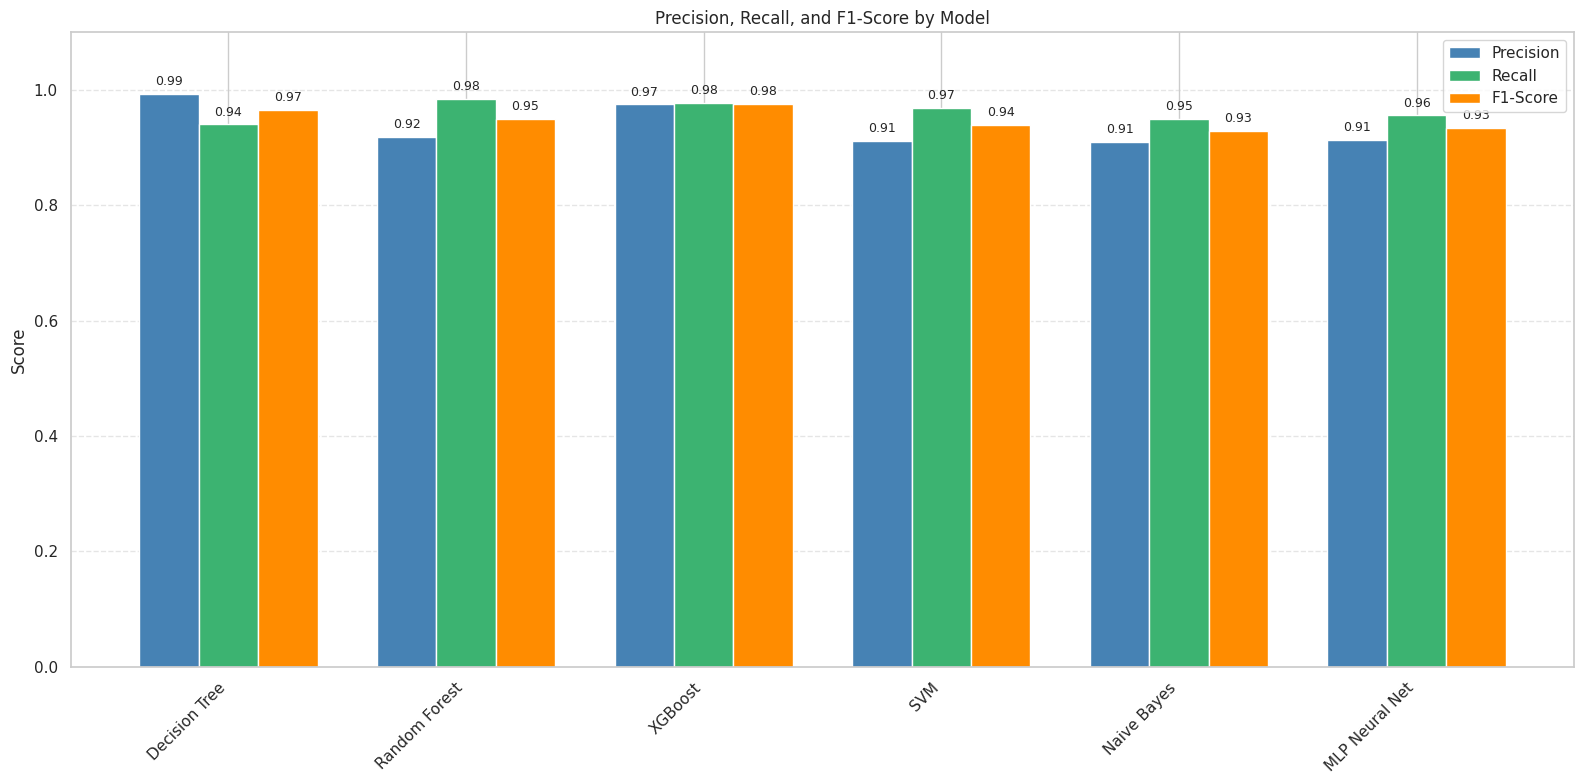

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

precisions = []
recalls = []
f1s = []
model_names = []

# Determine if problem is binary or multiclass
average_type = 'binary' if len(np.unique(y_test)) == 2 else 'macro'

for name, model in models.items():
    # Use scaled training and testing data
    model.fit(X_train_partial, y_train_partial)
    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1] if hasattr(model, "predict_proba") else None

    try:
        precisions.append(precision_score(y_test, y_pred, average=average_type))
        recalls.append(recall_score(y_test, y_pred, average=average_type))
        f1s.append(f1_score(y_test, y_pred, average=average_type))
        model_names.append(name)
    except Exception as e:
        print(f"[!] Skipping {name} due to error: {e}")

# Bar plot
x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(16, 8))
bars1 = plt.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = plt.bar(x, recalls, width, label='Recall', color='mediumseagreen')
bars3 = plt.bar(x + width, f1s, width, label='F1-Score', color='darkorange')

# Add labels above bars
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.xticks(x, model_names, rotation=45, ha='right')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.title('Precision, Recall, and F1-Score by Model')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


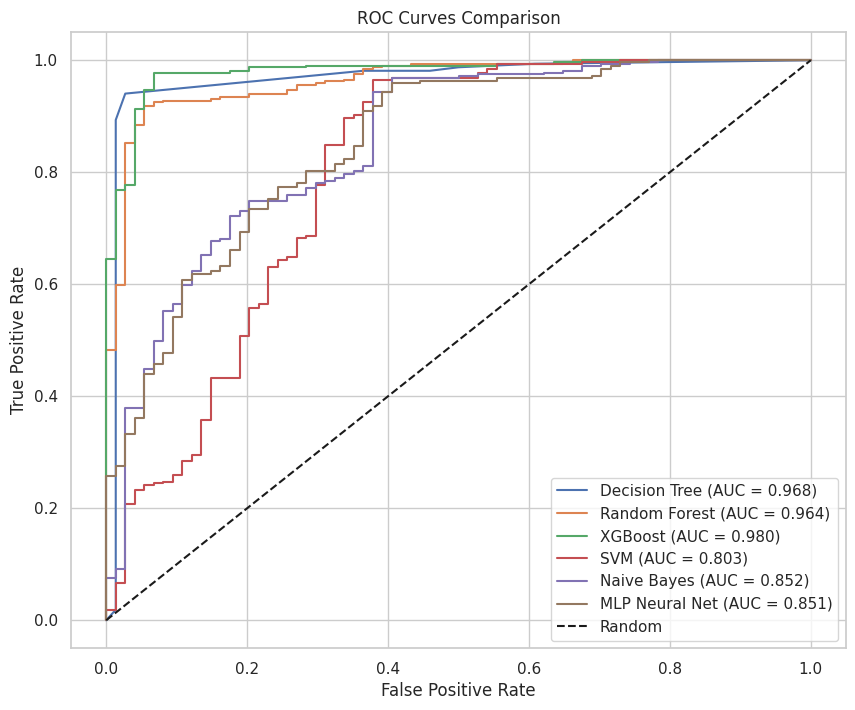

In [ ]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_partial, y_train_partial)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_sel)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


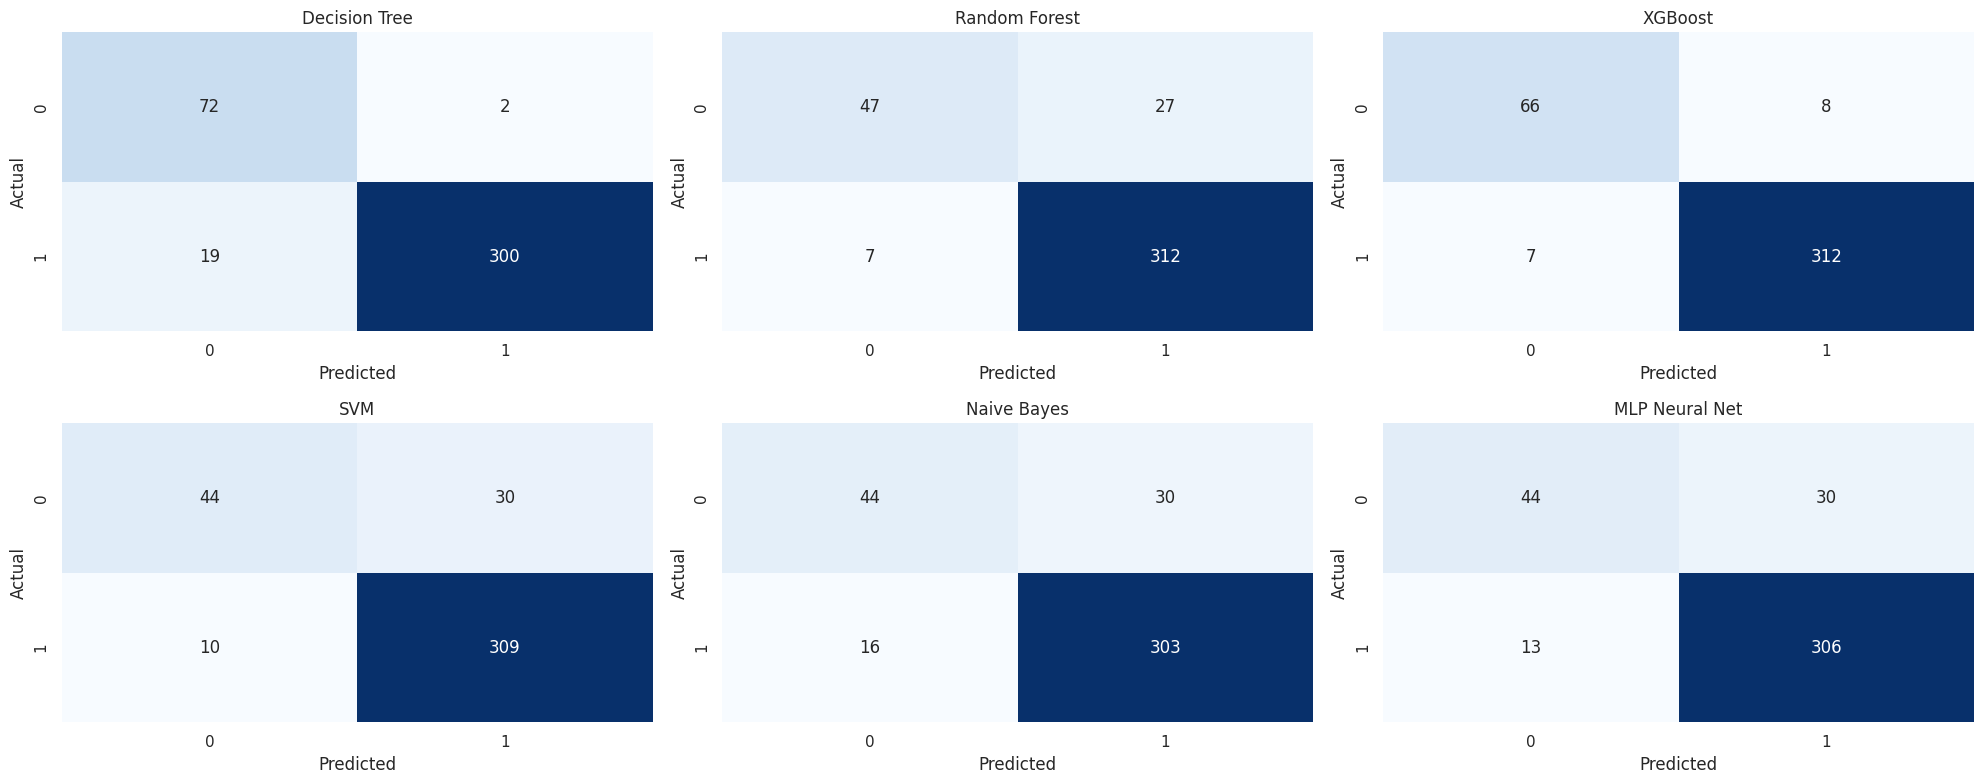

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_partial, y_train_partial)
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


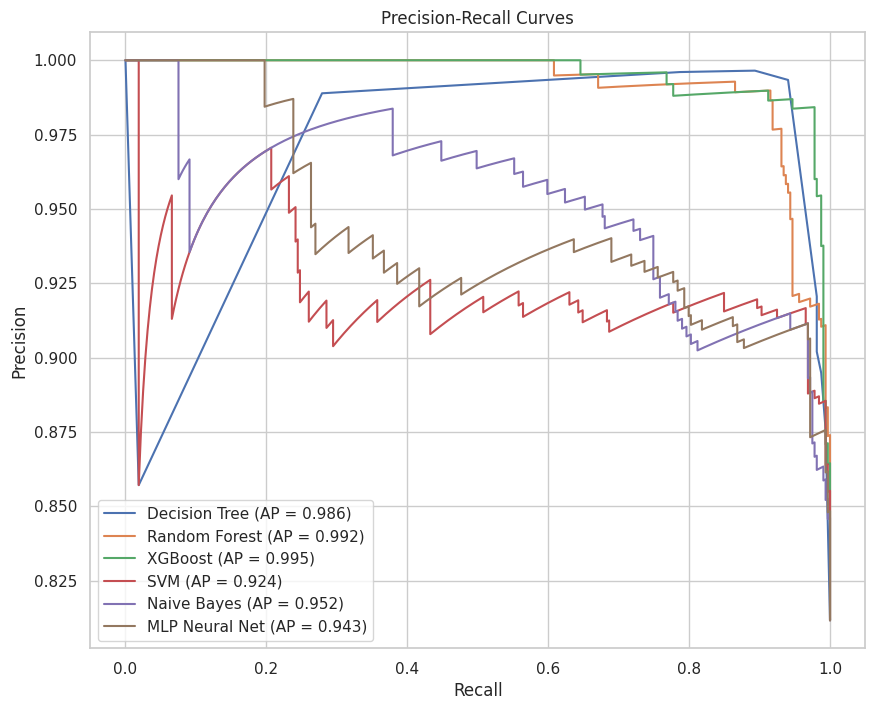

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,8))

for name, model in models.items():
    model.fit(X_train_partial, y_train_partial)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_sel)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        ap = average_precision_score(y_test, y_proba)
        plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_partial, y_train_partial, cv=cv, scoring='accuracy')
    print(f"{name}: CV Accuracy = {scores.mean():.4f} ± {scores.std():.4f}")


Decision Tree: CV Accuracy = 0.8988 ± 0.0207
Random Forest: CV Accuracy = 0.8769 ± 0.0080
XGBoost: CV Accuracy = 0.8997 ± 0.0104


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:54:36] WARNING: /w

SVM: CV Accuracy = 0.8642 ± 0.0151
Naive Bayes: CV Accuracy = 0.8541 ± 0.0144
MLP Neural Net: CV Accuracy = 0.8587 ± 0.0134


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'min_child_samples': [5, 10, 20]
}

lgb_model = lgb.LGBMClassifier(random_state=42)

rand_search = RandomizedSearchCV(lgb_model, param_distributions=param_dist,
                                 n_iter=10, scoring='accuracy', cv=cv,
                                 random_state=42, n_jobs=-1)

rand_search.fit(X_train_partial, y_train_partial)

print(f"Best params: {rand_search.best_params_}")
print(f"Best CV accuracy: {rand_search.best_score_:.4f}")


[LightGBM] [Info] Number of positive: 863, number of negative: 234
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 469
[LightGBM] [Info] Number of data points in the train set: 1097, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.786691 -> initscore=1.305094
[LightGBM] [Info] Start training from score 1.305094
Best params: {'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 5, 'learning_rate': 0.05}
Best CV accuracy: 0.8997


In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('lgb', lgb.LGBMClassifier(**rand_search.best_params_, random_state=42)),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
], voting='soft', n_jobs=-1)

ensemble.fit(X_train_partial, y_train_partial)
ensemble_acc = accuracy_score(y_test, ensemble.predict(X_test_sel))
print(f"Ensemble Test Accuracy: {ensemble_acc:.4f}")


Ensemble Test Accuracy: 0.9618


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


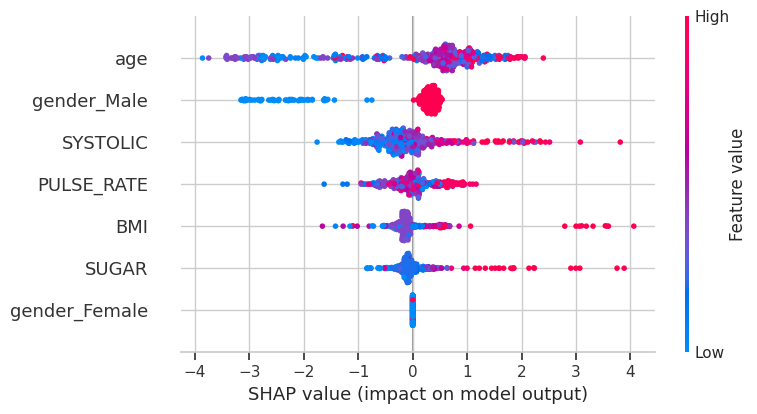

In [ ]:
import shap

# Use the LightGBM model from the ensemble for explanation
explainer = shap.TreeExplainer(ensemble.named_estimators_['lgb'])

# Calculate SHAP values using the scaled test data
shap_values = explainer.shap_values(X_test_sel)

# Use the original unscaled test data and feature names for the summary plot
shap.summary_plot(shap_values, X_test_sel, feature_names=X.columns)

In [ ]:
from sklearn.metrics import f1_score

y_proba = ensemble.predict_proba(X_test_sel)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best threshold for max F1-score: {best_thresh:.2f}")


Best threshold for max F1-score: 0.56


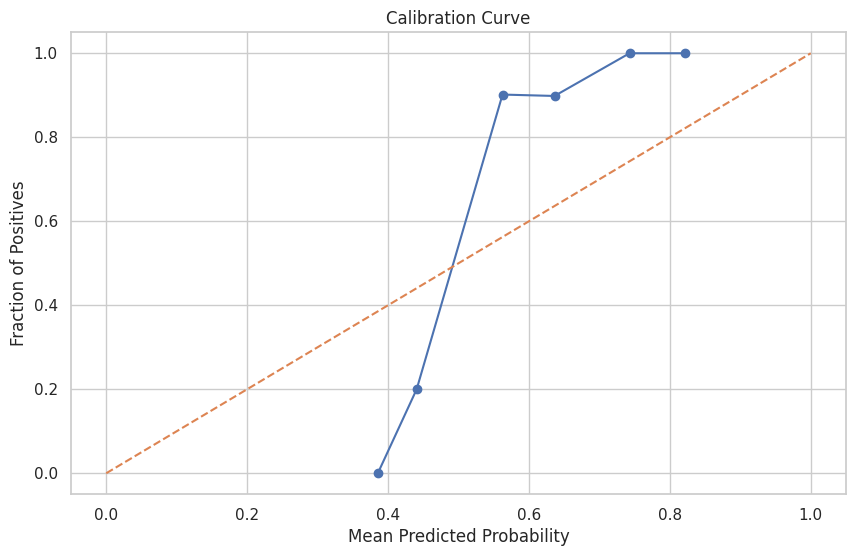

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.show()
